# Text Generation using GPT-2
- Fine-tuning on Shakespeare text
- Experimenting with different prompts


In [ ]:
!pip install transformers datasets accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer

with open("shakespeare.txt", "r", encoding="utf-8") as f:
    data = f.read()

dataset = Dataset.from_dict({"text": [data]})

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

In [ ]:
!pip install -U transformers

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("text-generation", model="sshleifer/tiny-gpt2")

Device set to use cpu


In [ ]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("sshleifer/tiny-gpt2")
model = AutoModelForCausalLM.from_pretrained("sshleifer/tiny-gpt2")

In [ ]:
from transformers import Trainer, TrainingArguments



training_args = TrainingArguments(
    output_dir="./results",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    save_steps=500,
    save_total_limit=2,
    logging_steps=100,
    warmup_steps=100,
    weight_decay=0.01,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
)


/tmp/ipython-input-10-2896942578.py:18: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

In [ ]:
from transformers import pipeline

generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

prompts = [
    "To be, or not to be, that is the question:",
    "Love is a smoke made with the fume of sighs.",
    "Thou art as wise as thou art beautiful."
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    outputs = generator(prompt, max_length=100, num_return_sequences=1, temperature=0.9)
    print(outputs[0]['generated_text'])


In [ ]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history
steps = [log["step"] for log in logs if "loss" in log]
losses = [log["loss"] for log in logs if "loss" in log]

plt.figure(figsize=(8,5))
plt.plot(steps, losses, label="Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss Over Steps")
plt.legend()
plt.grid(True)
plt.show()


Dataset Size: 2000


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Starting Training...


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
10,4.845050
20,4.151513
30,4.187200
40,3.886040
50,4.433375
60,4.278843
70,4.143986
80,3.565348
90,3.953013
100,3.998390


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Completed!

PROMPT : To be, or not to be
To be, or not to be; and to be.                           Exit                                     Exit          Exe

PROMPT : Love is a smoke
Love is a smoke, but a fire. We should have a very long time, when it comes. I'd have no more than a fire; they must be enough.                                                 

PROMPT : Thou art
Thou art no more than a master of this, and I know you. Then, sir, if you'd my son and thy wife, I'll go with you.                                                


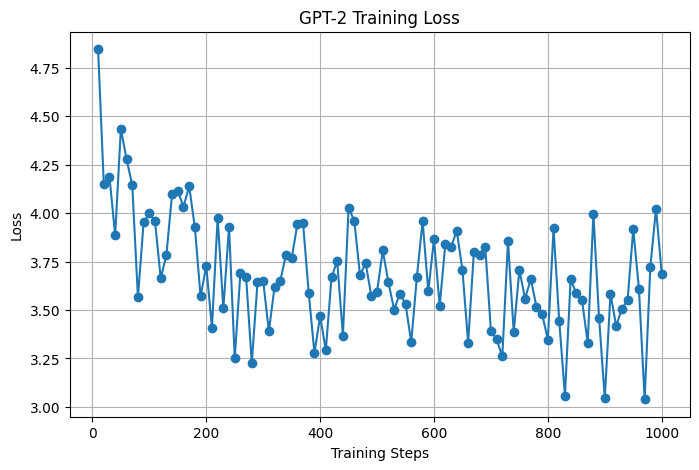

In [ ]:
# ============================================================
# WEEK 9 - SHAKESPEARE TEXT GENERATION USING GPT-2
# ============================================================

!pip install -q transformers datasets accelerate

import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

# ------------------------------------------------------------
# Load Shakespeare Dataset
# ------------------------------------------------------------

dataset = load_dataset(
    "text",
    data_files={"train": "shakespeare.txt"}
)

# Use only first 2000 lines for faster training
dataset["train"] = dataset["train"].select(range(2000))

print("Dataset Size:", len(dataset["train"]))

# ------------------------------------------------------------
# Load GPT-2 Tokenizer
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# ------------------------------------------------------------
# Tokenization Function
# ------------------------------------------------------------

def tokenize_function(examples):

    result = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

    result["labels"] = result["input_ids"].copy()

    return result

tokenized_dataset = dataset["train"].map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

# ------------------------------------------------------------
# Load GPT-2 Model
# ------------------------------------------------------------

model = AutoModelForCausalLM.from_pretrained("gpt2")

# ------------------------------------------------------------
# Data Collator
# ------------------------------------------------------------

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

# ------------------------------------------------------------
# Training Arguments
# ------------------------------------------------------------

training_args = TrainingArguments(
    output_dir="./gpt2_shakespeare",
    num_train_epochs=1,
    per_device_train_batch_size=2,
    logging_steps=10,
    save_steps=500,
    save_total_limit=1,
    report_to="none"
)

# ------------------------------------------------------------
# Trainer
# ------------------------------------------------------------

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator
)

# ------------------------------------------------------------
# Train GPT-2
# ------------------------------------------------------------

print("Starting Training...")

trainer.train()

print("Training Completed!")

# ------------------------------------------------------------
# Generate Shakespeare Text
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

prompts = [
    "To be, or not to be",
    "Love is a smoke",
    "Thou art"
]

for prompt in prompts:

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    output = model.generate(
        **inputs,
        max_new_tokens=80,
        do_sample=True,
        temperature=0.8,
        top_k=50,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_text = tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    print("\n" + "="*60)
    print("PROMPT :", prompt)
    print("="*60)
    print(generated_text)

# ------------------------------------------------------------
# Plot Training Loss
# ------------------------------------------------------------

logs = trainer.state.log_history

steps = []
losses = []

for log in logs:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

plt.figure(figsize=(8,5))
plt.plot(steps, losses, marker='o')
plt.title("GPT-2 Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.show()